# 10 — SHAP: Explicabilidade por Cluster

**Objetivo:** identificar quais features mais contribuem para a formação de cada cluster,
e explicar individualmente por que cada município foi classificado como foi.

**Abordagem:** treinar um classificador surrogate (Random Forest multiclasse) para predizer
`kmeans_cluster` a partir das 20 features originais, e aplicar SHAP (TreeExplainer) sobre ele.

| Seção | Conteúdo |
|---|---|
| 1. Surrogate | Treinamento e avaliação do RF (accuracy, confusion matrix) |
| 2. SHAP global | Importância agregada de cada feature para separar os 5 clusters |
| 3. SHAP por cluster | Quais features definem cada perfil (C0–C4) |
| 4. SHAP por município | Waterfall plots de casos representativos |
| 5. SHAP + LOF | Features que explicam as anomalias individuais |

**Entrada:** `rqual_2022_clusterizado_v2.parquet`  
**Saída:** `shap_importancia_por_cluster.csv`, `shap_explicacoes_municipios.csv`, figuras


In [1]:
# Bloco 0 — Setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from pathlib import Path
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ARQ = Path('rqual_2022_clusterizado_v2.parquet')

CLUSTER_NOMES = {
    0: 'C0: Urbano-Avançado',
    1: 'C1: Intermediário',
    2: 'C2: Nordeste Periférico',
    3: 'C3: Norte/Amazônico',
    4: 'C4: Capitais',
}
CORES = ['#1976D2','#388E3C','#F57C00','#D32F2F','#7B1FA2']

print('Setup concluído. SHAP:', shap.__version__)


Setup concluído. SHAP: 0.47.2


## 1. Dados e Features


In [2]:
# Bloco 1 — Carregar dados e definir features
df = pd.read_parquet(ARQ)
print(f'Shape: {df.shape}')

# Colunas de identificação e meta
ID_COLS  = ['cod_mun','uf_rqual','nome_mun_rqual']
META_COLS = ['kmeans_cluster','hdbscan_cluster','hdbscan_noise',
             'umap_x','umap_y','umap_hdbscan_global','umap_hdbscan_local',
             'lof_score','lof_outlier']

# Features usadas pelo K-Means (mesmas 20 do pipeline)
EXCLUIR = set(ID_COLS) | set(META_COLS)
FEAT_COLS_RAW = [c for c in df.columns if c not in EXCLUIR]

# Renomear para nomes curtos (legibilidade nos gráficos SHAP)
RENAME = {
    'Código da Grande Região': 'regiao_cod',
    'LAT__capital': 'capital',
    'LAT__siafi_id': 'siafi_id',
    'LAT__ddd': 'ddd',
}
df = df.rename(columns=RENAME)
FEAT_COLS = [RENAME.get(c, c) for c in FEAT_COLS_RAW]

# Features analíticas (excluindo códigos administrativos)
ADMIN_COLS  = ['capital', 'siafi_id', 'ddd', 'regiao_cod']
FEAT_ANALITICAS = [c for c in FEAT_COLS if c not in ADMIN_COLS]

print(f'\nTotal de features: {len(FEAT_COLS)}')
print(f'  Analíticas (usadas no SHAP principal): {len(FEAT_ANALITICAS)}')
print(f'  Administrativas (excluídas): {ADMIN_COLS}')
print(f'\nFeatures analíticas:')
for f in FEAT_ANALITICAS: print(f'  {f}')

X = df[FEAT_ANALITICAS].astype(float)
y = df['kmeans_cluster']
print(f'\nMissings: {X.isna().sum().sum()}')


Shape: (5570, 32)

Total de features: 20
  Analíticas (usadas no SHAP principal): 16
  Administrativas (excluídas): ['capital', 'siafi_id', 'ddd', 'regiao_cod']

Features analíticas:
  IND2
  IND4
  IND5
  IND8
  IND9
  INF1
  INF4-UP
  pib_agropecuaria
  pib_industria
  pib_per_capita
  area_km2
  densidade
  lat
  lon
  pop_rural
  idhm

Missings: 0


## 2. Surrogate — Random Forest Multiclasse

Um classificador RF aprende a reproduzir as fronteiras do K-Means. SHAP é então aplicado
sobre o RF — que é transparente o suficiente para explicações fiéis.


In [3]:
# Bloco 2 — Treinar surrogate Random Forest
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
rf = RandomForestClassifier(**RF_PARAMS)
rf.fit(X, y)

# Validação cruzada estratificada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print('=' * 50)
print('SURROGATE — Random Forest')
print('=' * 50)
print(f'Accuracy CV-5:  {scores.mean():.3f} ± {scores.std():.3f}')
print(f'Accuracy treino: {rf.score(X, y):.3f}')
print()
print('Quanto maior a accuracy, mais fiel o SHAP ao K-Means original.')
print('Accuracy > 0.95 indica que o RF reproduz bem as fronteiras dos clusters.')


SURROGATE — Random Forest
Accuracy CV-5:  0.950 ± 0.006
Accuracy treino: 0.980

Quanto maior a accuracy, mais fiel o SHAP ao K-Means original.
Accuracy > 0.95 indica que o RF reproduz bem as fronteiras dos clusters.


Classification Report:
                         precision    recall  f1-score   support

    C0: Urbano-Avançado       0.91      0.97      0.94       216
      C1: Intermediário       0.99      0.99      0.99      3054
C2: Nordeste Periférico       0.98      0.98      0.98      2057
    C3: Norte/Amazônico       0.98      0.93      0.95       216
           C4: Capitais       1.00      0.33      0.50        27

               accuracy                           0.98      5570
              macro avg       0.97      0.84      0.87      5570
           weighted avg       0.98      0.98      0.98      5570



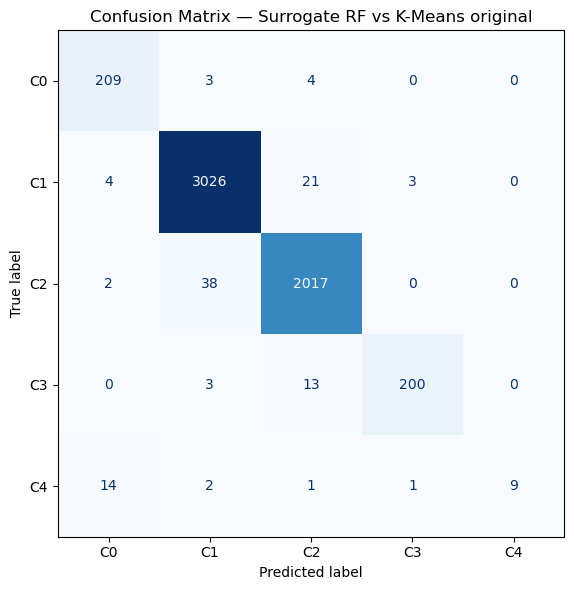

Salvo: fig_shap_confusion_matrix.png


In [4]:
# Bloco 2B — Confusion matrix e classification report
y_pred = rf.predict(X)

print('Classification Report:')
print(classification_report(
    y, y_pred,
    target_names=[CLUSTER_NOMES[k] for k in sorted(CLUSTER_NOMES)]
))

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f'C{k}' for k in sorted(CLUSTER_NOMES)]
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Surrogate RF vs K-Means original', fontsize=12)
plt.tight_layout()
plt.savefig('fig_shap_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_shap_confusion_matrix.png')


## 3. SHAP Global — Importância por Feature

O TreeExplainer calcula o SHAP value de cada feature para cada município e cada cluster.
O valor SHAP indica **quanto aquela feature empurrou a predição para aquele cluster** (positivo = favorece, negativo = desfavorece).


In [5]:
# Bloco 3 — Calcular SHAP values (TreeExplainer)
# SHAP >= 0.40: explainer(X).values retorna array [n_samples, n_features, n_classes]
print('Calculando SHAP values... (pode levar ~30s)')
explainer   = shap.TreeExplainer(rf)
explanation = explainer(X)                        # Explanation object
shap_vals   = explanation.values                   # [5570, 16, 5]
print(f'SHAP calculado: shape = {shap_vals.shape}  (amostras × features × classes)')

# Acesso por classe k: shap_vals[:, :, k] -> [5570, 16]
# Importância global: média |SHAP| sobre todas as classes e amostras
importancia_global = pd.Series(
    np.abs(shap_vals).mean(axis=2).mean(axis=0),
    index=FEAT_ANALITICAS
).sort_values(ascending=False)

print('\nImportância global (média |SHAP| sobre todos os clusters):')
display(importancia_global.round(4).rename('shap_mean_abs').reset_index()
        .rename(columns={'index':'feature'}))


Calculando SHAP values... (pode levar ~30s)


SHAP calculado: shape = (5570, 16, 5)  (amostras × features × classes)

Importância global (média |SHAP| sobre todos os clusters):


,feature,shap_mean_abs
0,idhm,0.0675
1,lat,0.0531
2,lon,0.0316
3,pib_per_capita,0.0308
4,pib_industria,0.0151
5,area_km2,0.0146
6,pop_rural,0.0141
7,densidade,0.0125
8,IND5,0.0108
9,pib_agropecuaria,0.0052


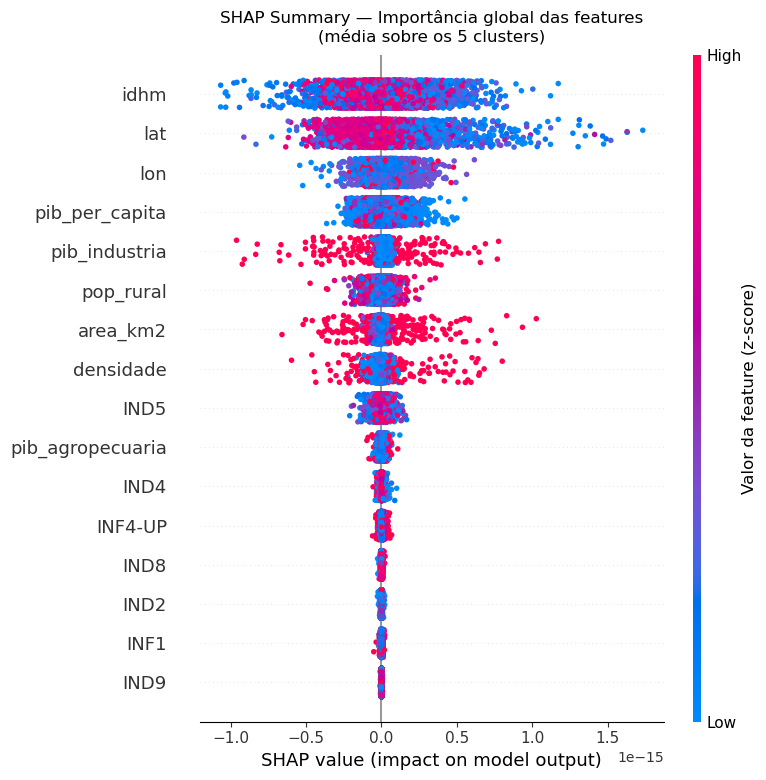

Salvo: fig_shap_summary_global.png


In [6]:
# Bloco 3B — Summary plot global (beeswarm)
# Para summary_plot passamos a média dos shap_vals sobre as classes
shap_mean_over_classes = shap_vals.mean(axis=2)  # [5570, 16]

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_mean_over_classes,
    X,
    feature_names=FEAT_ANALITICAS,
    show=False,
    plot_type='dot',
    max_display=16,
    color_bar_label='Valor da feature (z-score)',
)
plt.title('SHAP Summary — Importância global das features\n'
          '(média sobre os 5 clusters)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('fig_shap_summary_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_shap_summary_global.png')


## 4. SHAP por Cluster — O que define cada perfil?

Para cada cluster, calculamos a **importância média |SHAP|** das features *apenas para os municípios
pertencentes a esse cluster*. Isso responde: 'quais features mais contribuíram para classificar
esses municípios neste cluster específico?'


In [7]:
# Bloco 4 — Importância SHAP por cluster
df_shap_por_cluster = {}

for k in range(5):
    idx_k  = np.where(y == k)[0]
    sv_k   = shap_vals[idx_k, :, k]          # [n_k, 16]
    imp_k  = pd.Series(np.abs(sv_k).mean(axis=0), index=FEAT_ANALITICAS)
    df_shap_por_cluster[CLUSTER_NOMES[k]] = imp_k

df_imp = pd.DataFrame(df_shap_por_cluster)

print('Importância SHAP por cluster (média |SHAP| nos municípios do cluster):')
display(df_imp.round(4))

df_imp.to_csv('shap_importancia_por_cluster.csv')
print('\nSalvo: shap_importancia_por_cluster.csv')


Importância SHAP por cluster (média |SHAP| nos municípios do cluster):


,C0: Urbano-Avançado,C1: Intermediário,C2: Nordeste Periférico,C3: Norte/Amazônico,C4: Capitais
IND2,0.0039,0.0015,0.0010,0.0018,0.0049
IND4,0.0081,0.0055,0.0049,0.0253,0.0125
IND5,0.0193,0.0229,0.0186,0.0643,0.0141
IND8,0.0012,0.0013,0.0017,0.0035,0.0015
IND9,0.0048,0.0008,0.0013,0.0008,0.0083
INF1,0.0059,0.0018,0.0015,0.0018,0.0064
INF4-UP,0.0207,0.0051,0.0030,0.0028,0.0129
pib_agropecuaria,0.0105,0.0092,0.0112,0.0225,0.0058
pib_industria,0.3231,0.0268,0.0076,0.0093,0.0957
pib_per_capita,0.0604,0.0653,0.0882,0.0150,0.0319



Salvo: shap_importancia_por_cluster.csv


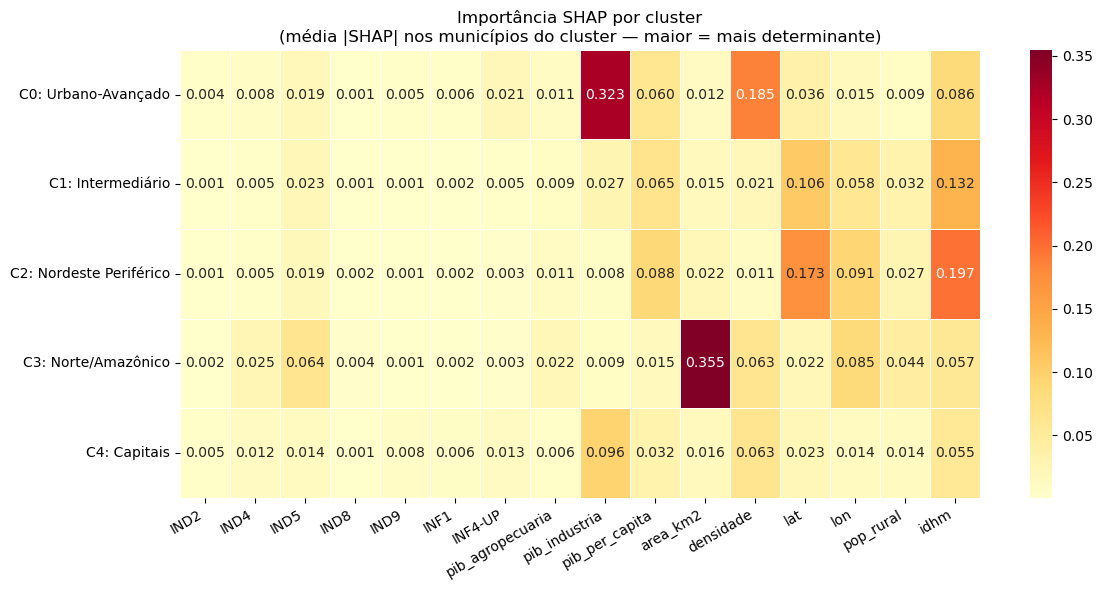

Salvo: fig_shap_heatmap_clusters.png


In [8]:
# Bloco 4B — Heatmap de importância SHAP por cluster
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    df_imp.T,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Importância SHAP por cluster\n(média |SHAP| nos municípios do cluster — maior = mais determinante)', fontsize=12)
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_shap_heatmap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_shap_heatmap_clusters.png')


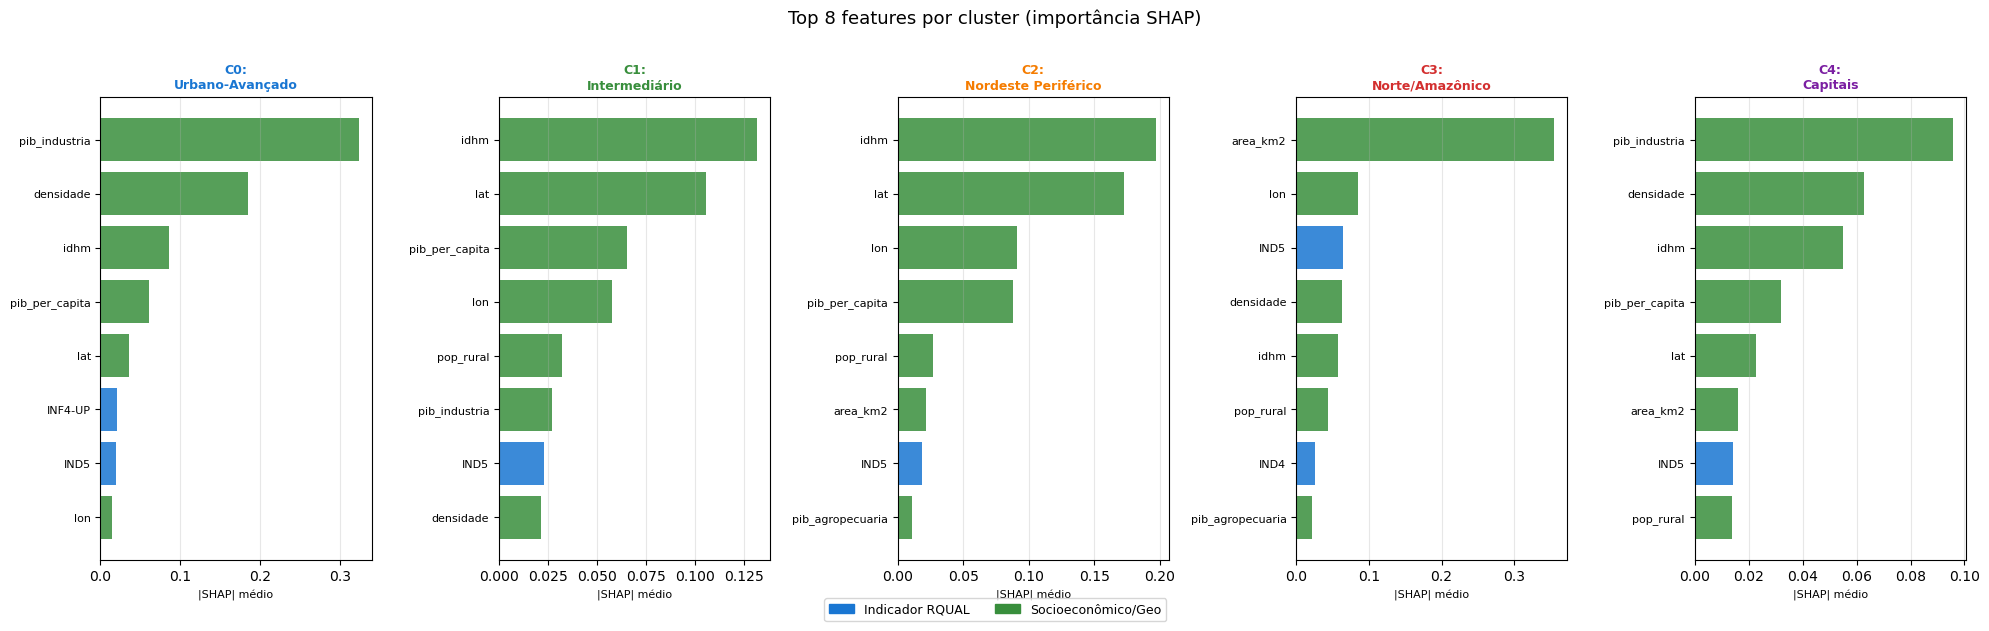

Salvo: fig_shap_barras_por_cluster.png


In [9]:
# Bloco 4C — Bar plots individuais por cluster (top 8 features)
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=False)

for k, ax in enumerate(axes):
    top8 = df_imp[CLUSTER_NOMES[k]].sort_values(ascending=False).head(8)
    cor_barras = ['#1976D2' if f in ['IND2','IND4','IND5','IND8','IND9','INF1','INF4-UP']
                  else '#388E3C' for f in top8.index]
    ax.barh(top8.index[::-1], top8.values[::-1], color=cor_barras[::-1], alpha=0.85)
    ax.set_title(CLUSTER_NOMES[k].replace(': ', ':\n'), fontsize=9, fontweight='bold',
                 color=CORES[k])
    ax.set_xlabel('|SHAP| médio', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)

patch_rqual = mpatches.Patch(color='#1976D2', label='Indicador RQUAL')
patch_socio = mpatches.Patch(color='#388E3C', label='Socioeconômico/Geo')
fig.legend(handles=[patch_rqual, patch_socio], loc='lower center',
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Top 8 features por cluster (importância SHAP)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_shap_barras_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_shap_barras_por_cluster.png')


## 5. SHAP por Município — Casos Representativos

O waterfall plot mostra quanto cada feature *empurrou* a predição do município
para o cluster ao qual pertence. Leitura: vermelho = feature favorece o cluster, azul = desfavorece.


Municípios representativos selecionados:
  C0 — Cotia/SP
  C1 — Cipotânea/MG
  C2 — Curuá/PA
  C3 — Coari/AM
  C4 — Fortaleza/CE


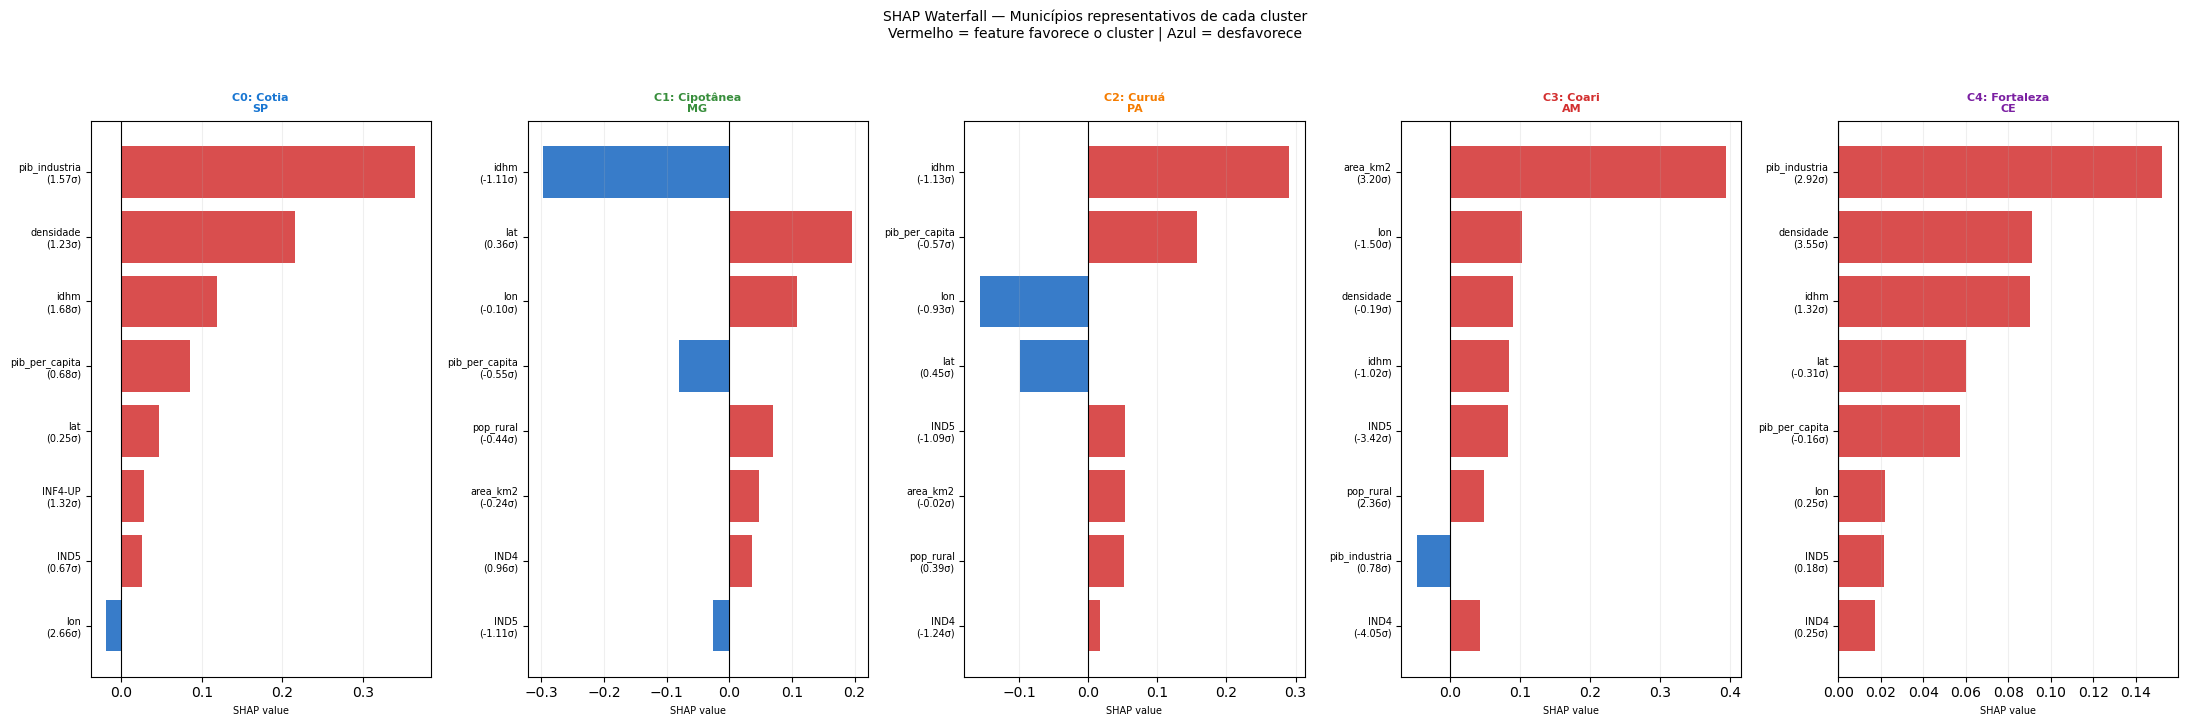

Salvo: fig_shap_waterfall_representativos.png


In [10]:
# Bloco 5 — Waterfall de municípios representativos
casos = []
for k in range(5):
    idx_k    = np.where(y == k)[0]
    sv_k     = shap_vals[idx_k, :, k]    # [n_k, 16]
    soma_abs = np.abs(sv_k).sum(axis=1)
    mais_tipico = idx_k[soma_abs.argmax()]
    casos.append((k, mais_tipico,
                  df.iloc[mais_tipico]['nome_mun_rqual'],
                  df.iloc[mais_tipico]['uf_rqual']))

print('Municípios representativos selecionados:')
for k, idx, nome, uf in casos:
    print(f'  C{k} — {nome}/{uf}')

fig, axes = plt.subplots(1, 5, figsize=(22, 7))

for ax, (k, idx, nome, uf) in zip(axes, casos):
    sv = shap_vals[idx, :, k]          # [16] — SHAP do município para classe k
    order  = np.argsort(np.abs(sv))[::-1][:8]
    feats_ord = [FEAT_ANALITICAS[i] for i in order]
    vals_ord  = sv[order]
    xvals_ord = X.iloc[idx].values[order]

    cores_bar = ['#D32F2F' if v > 0 else '#1565C0' for v in vals_ord]
    ax.barh(range(len(feats_ord)), vals_ord[::-1], color=cores_bar[::-1], alpha=0.85)
    ax.set_yticks(range(len(feats_ord)))
    ax.set_yticklabels(
        [f'{f}\n({xvals_ord[::-1][i]:.2f}σ)' for i, f in enumerate(feats_ord[::-1])],
        fontsize=7
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'C{k}: {nome}\n{uf}', fontsize=8, fontweight='bold', color=CORES[k])
    ax.set_xlabel('SHAP value', fontsize=7)
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('SHAP Waterfall — Municípios representativos de cada cluster\n'
             'Vermelho = feature favorece o cluster | Azul = desfavorece',
             fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig('fig_shap_waterfall_representativos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_shap_waterfall_representativos.png')


## 6. SHAP + LOF — O que explica as anomalias individuais?

Combinamos a pontuação LOF (magnitude da anomalia) com o SHAP (direção da anomalia).
Para os municípios com maior LOF score, identificamos *qual feature* mais os afasta do padrão do cluster.


In [11]:
# Bloco 6 — SHAP + LOF: features que explicam os top outliers
# Construir matriz SHAP referente ao cluster de cada município
shap_proprio_cluster = np.zeros((len(df), len(FEAT_ANALITICAS)))
for k in range(5):
    idx_k = np.where(y == k)[0]
    shap_proprio_cluster[idx_k] = shap_vals[idx_k, :, k]

df_shap_matrix = pd.DataFrame(shap_proprio_cluster, columns=FEAT_ANALITICAS, index=df.index)

df['shap_dominante']       = df_shap_matrix.abs().idxmax(axis=1)
df['shap_dominante_valor'] = df_shap_matrix.abs().max(axis=1)

top_lof = (
    df[df['lof_outlier']]
    .nlargest(20, 'lof_score')
    [['nome_mun_rqual','uf_rqual','kmeans_cluster','lof_score',
      'shap_dominante','shap_dominante_valor']]
    .reset_index(drop=True)
)
top_lof['cluster_nome'] = top_lof['kmeans_cluster'].map(CLUSTER_NOMES)

print('Top 20 outliers LOF com feature SHAP mais determinante:')
display(top_lof[['nome_mun_rqual','uf_rqual','cluster_nome',
                 'lof_score','shap_dominante','shap_dominante_valor']]
        .rename(columns={'nome_mun_rqual':'município','uf_rqual':'UF',
                         'cluster_nome':'cluster','lof_score':'LOF score',
                         'shap_dominante':'feature dominante',
                         'shap_dominante_valor':'|SHAP|'})
        .round(3))


Top 20 outliers LOF com feature SHAP mais determinante:


,município,UF,cluster,LOF score,feature dominante,|SHAP|
0,Águas de São Pedro,SP,C1: Intermediário,2.266,densidade,0.179
1,São Bento do Norte,RN,C2: Nordeste Periférico,2.225,lat,0.240
2,Fernando de Noronha,PE,C2: Nordeste Periférico,2.010,idhm,0.203
3,Camargo,RS,C1: Intermediário,1.988,idhm,0.139
4,Curionópolis,PA,C2: Nordeste Periférico,1.975,lat,0.360
5,Parazinho,RN,C2: Nordeste Periférico,1.967,lat,0.259
6,Campo Alegre de Goiás,GO,C1: Intermediário,1.920,idhm,0.155
7,São Vendelino,RS,C1: Intermediário,1.885,idhm,0.127
8,Tunas,RS,C1: Intermediário,1.880,idhm,0.109
9,Toritama,PE,C2: Nordeste Periférico,1.867,lat,0.262


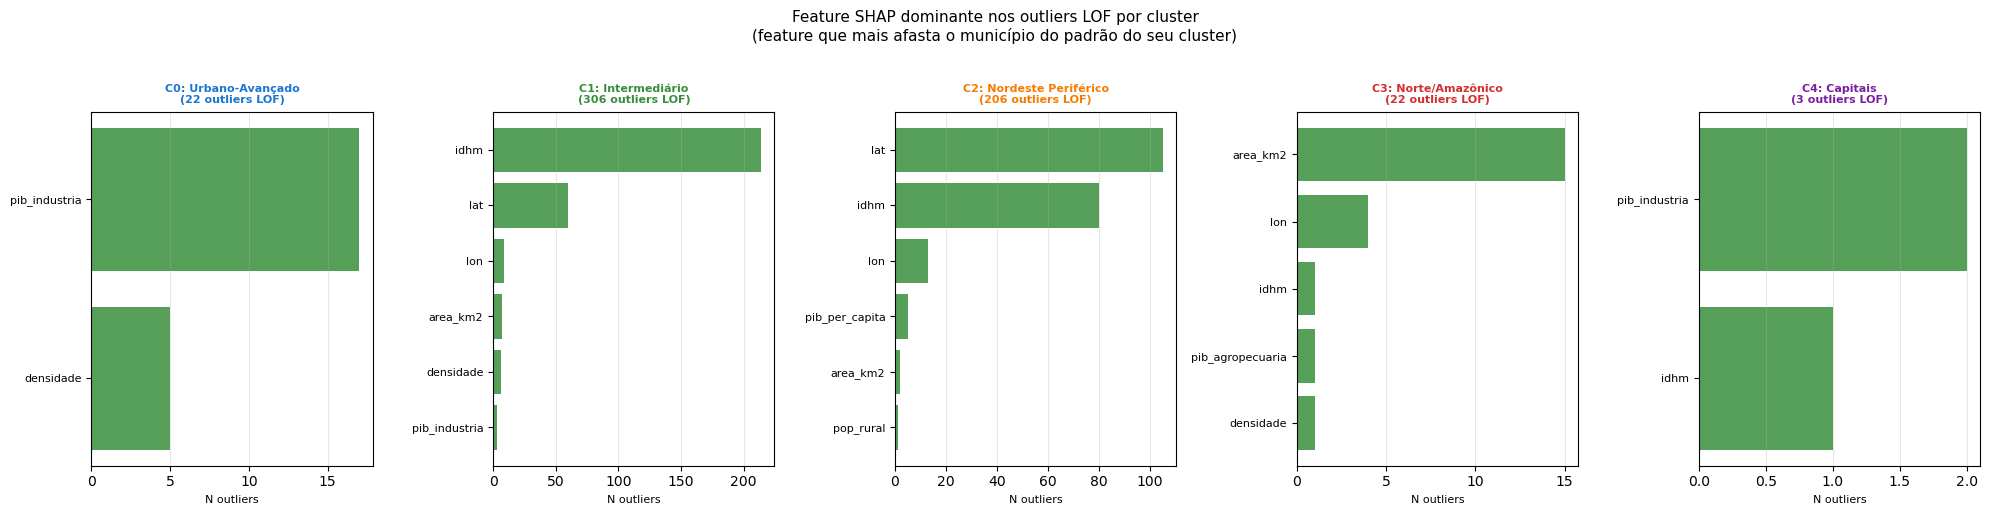

Salvo: fig_shap_lof_features_dominantes.png


In [12]:
# Bloco 6B — Distribuição de features dominantes nos outliers LOF por cluster
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for k, ax in enumerate(axes):
    lof_k = df[(df['kmeans_cluster'] == k) & (df['lof_outlier'])]
    if len(lof_k) == 0:
        ax.set_visible(False)
        continue
    contagem = lof_k['shap_dominante'].value_counts().head(6)
    cores_feat = ['#1976D2' if f in ['IND2','IND4','IND5','IND8','IND9','INF1','INF4-UP']
                  else '#388E3C' for f in contagem.index]
    ax.barh(contagem.index[::-1], contagem.values[::-1], color=cores_feat[::-1], alpha=0.85)
    ax.set_title(f'{CLUSTER_NOMES[k]}\n({len(lof_k)} outliers LOF)', fontsize=8,
                 fontweight='bold', color=CORES[k])
    ax.set_xlabel('N outliers', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Feature SHAP dominante nos outliers LOF por cluster\n'
             '(feature que mais afasta o município do padrão do seu cluster)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_shap_lof_features_dominantes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_shap_lof_features_dominantes.png')


## 7. Exportação


In [13]:
# Bloco E — Exportar resultados

# 1. Importância por cluster
df_imp.to_csv('shap_importancia_por_cluster.csv')
print('Salvo: shap_importancia_por_cluster.csv')

# 2. Explicações individuais (feature dominante + valor SHAP para todos os municípios)
cols_export = ['cod_mun','nome_mun_rqual','uf_rqual','kmeans_cluster',
               'lof_score','lof_outlier','shap_dominante','shap_dominante_valor']
df[cols_export].to_csv('shap_explicacoes_municipios.csv', index=False)
print('Salvo: shap_explicacoes_municipios.csv')

# 3. SHAP matrix completa (feature × município)
df_shap_export = df_shap_matrix.copy()
df_shap_export.insert(0, 'cod_mun', df['cod_mun'].values)
df_shap_export.insert(1, 'nome_mun_rqual', df['nome_mun_rqual'].values)
df_shap_export.insert(2, 'kmeans_cluster', df['kmeans_cluster'].values)
df_shap_export.to_csv('shap_matrix_completa.csv', index=False)
print('Salvo: shap_matrix_completa.csv')

print(f'\nTotal de municípios explicados: {len(df):,}')
print(f'Features no modelo SHAP: {len(FEAT_ANALITICAS)}')


Salvo: shap_importancia_por_cluster.csv
Salvo: shap_explicacoes_municipios.csv
Salvo: shap_matrix_completa.csv

Total de municípios explicados: 5,570
Features no modelo SHAP: 16
